# 🌊 Satellite Correction - CAWCR Spectrum (Optional)

> **Inputs:**
> - Wave spectrum to be corrected in `.nc` format, located in the `inputs/` folder.
> - Satellite data in `.nc` format, also located in the `inputs/` folder.
> - *Optional:* Wave buoy data for validating the satellite-based correction.
>
> **⚠️NOTE:** Instructions for downloading the satellite data are available at:  
> https://github.com/javitausia/CalValWaves
>
> **Outputs:**
> - Satellite-corrected wave spectrum in `.nc` format, saved in the `inputs/` folder.  
>   This file can be used either for Super-Point construction (if needed) or directly as input for BinWaves.

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk

- **BlueMath Toolkit Repository**:  [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

Before continuing, ensure you have **created and activated a Python environment**.

*** Other Required Packages ***
- `wavespectra` 
- `cartophy`
 
---



This Jupyter Notebook is an alternative step to correct CAWCR or other hindcast data with Satellite information. The corrected spectra can be use: 

1. Create the SuperPoint (Cagigal et al., 2023)
2. As a input to teh BinWaves Reconstrcution Notebook.

---
<details open>


The hindcast significant wave height data can be calibrated using both buoy and satellite significant height of waves as the "good" measure, but the way we prefer to do it is calibrating first with the satellite data and validating with the buoy after the calibration. A description of what is done can be seen in this paper:

João Albuquerque, Jose A. A. Antolínez, Ana Rueda, Fernando J.Méndez, Giovanni Cocoa (November 2018). Directional correction of modeled sea and swell wave heights using satellite altimeter data. https://doi.org/10.1016/j.ocemod.2018.09.001


<summary><strong>📁 CalVaL</strong></summary>

More information about teh satellite correction can be found in  [https://github.com/javitausia/CalValWaves/tree/master/](https://github.com/javitausia/CalValWaves/tree/master) 

</details>

---


In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import os.path as op
from numpy import atan2
import wavespectra

In [2]:
STATION_ID = '4466'  
station_lat=33.4400
station_lon=-77.7600+360
p_data = op.join(os.getcwd())
output_folder = op.join(p_data, 'outputs')

In [3]:
cawcr_spectrum = xr.open_dataset(
    op.join(p_data, 'inputs/CAWCR_spectra', 'CAWCR_4466.nc')
).sortby('direction').rename({
    'u10m': 'Wspeed',
    'udir': 'Wdir',
    'depth': 'Depth',
    'frequency': 'freq',
    'direction': 'dir'
})

# NOTE: The direction is in degrees, but efth is in m Hz rad^-1, therefor we need to convert the efth to degrees to be cohetent with the rest of the code
efth_deg = cawcr_spectrum.efth * (np.pi/180.0)
cawcr_spectrum['efth'] = efth_deg
# NOTE: fix csiro direction for wavespectra (from -> to)'
cawcr_spectrum['Wdir'] = (cawcr_spectrum.Wdir - 180) % 360 
cawcr_spectrum['dir'] = (cawcr_spectrum.dir - 180) % 360
cawcr_spectrum

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 405963, freq: 29, dir: 24)
Coordinates:
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    station    int32 4B ...
  * freq       (freq) float32 116B 0.035 0.0385 0.04235 ... 0.4171 0.4589 0.5047
  * dir        (dir) float32 96B 187.5 202.5 217.5 232.5 ... 142.5 157.5 172.5
Data variables:
    longitude  (time) float32 2MB ...
    latitude   (time) float32 2MB ...
    efth       (time, freq, dir) float32 1GB 0.0 0.0 0.0 ... 9.603e-05 0.0001503
    Depth      (time) float32 2MB ...
    Wspeed     (time) float32 2MB ...
    Wdir       (time) float32 2MB 349.9 349.9 349.7 347.1 ... 40.65 42.05 39.99
Attributes: (12/23)
    product_name:           ww3.197901_spec.nc
    area:                   spectral resolution for points
    data_type:              OCO spectra 2D
    format_version:         1.1
    southernmost_latitude:  -70.0000000°
    northernmost_latitude:  71.5999985°
    ...                     ...
    author:                 Durrant, Hemer, Trenham and Greenslade
    contact:                Mark.Hemer@csiro.au,T.Durrant@bom.gov.au
    DOI:                    http://dx.doi.org/10.4225/08/523168703DCC5
    related_materials:      Centre for Australian Weather and Climate Researc...
    creation_method:        The hindcast was performed using the WAVEWATCH II...
    license:                Please note that the licensee is required to ackn...

In [4]:
nswells = 5
do_parts = False

if do_parts:
    spec_parts = cawcr_spectrum.spec.partition.ptm1(
        wspd=cawcr_spectrum.Wspeed,
        wdir= cawcr_spectrum.Wdir,
        dpt=cawcr_spectrum.Depth,
        swells=nswells
    )
    spec_parts_stats = spec_parts.spec.stats(['hs', 'tp', 'dpm'])
    spec_parts.to_netcdf(op.join(output_folder, 'CAWCR_spectral_parts_4466.nc'))
    spec_parts_stats.to_netcdf(op.join(output_folder, 'CAWCR_ds_parts_stats_4466.nc'))
else:
    spec_parts = xr.open_dataset(op.join(output_folder, 'CAWCR_spectral_parts_4466.nc'))
    spec_parts_stats = xr.open_dataset(op.join(output_folder, 'CAWCR_ds_parts_stats_4466.nc'))

In [5]:
csiro = pd.DataFrame({
    'Hs':cawcr_spectrum.efth.spec.hs().values,
    'Dm':cawcr_spectrum.efth.spec.dm().values,
    'Tp':cawcr_spectrum.efth.spec.tp().values,
    'DirM':cawcr_spectrum.efth.spec.dpm().values,
    'Hsea': spec_parts_stats['hs'].isel(part=0).values,
    'Hswell1': spec_parts_stats['hs'].isel(part=1).values,
    'Hswell2': spec_parts_stats['hs'].isel(part=2).values,
    'Hswell3': spec_parts_stats['hs'].isel(part=3).values,
    'Dirsea': spec_parts_stats['dpm'].isel(part=0).values,
    'Dirswell1': spec_parts_stats['dpm'].isel(part=1).values,
    'Dirswell2': spec_parts_stats['dpm'].isel(part=2).values,
    'Dirswell3': spec_parts_stats['dpm'].isel(part=3).values,
}, index=pd.to_datetime(spec_parts_stats['time'].values))

# Fill NaNs with 0.0 for Hs components
for col in ['Hsea', 'Hswell1', 'Hswell2', 'Hswell3']:
    csiro[col] = csiro[col].fillna(0.0)
# Round index to the nearest hour if needed
csiro.index = csiro.index.round('H')
lat = float(station_lat)
lon = float(station_lon)
csiro_lon, csiro_lat = lon, lat
csiro

/tmp/ipykernel_1663405/4223863775.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  csiro.index = csiro.index.round('H')


,Hs,Dm,Tp,DirM,Hsea,Hswell1,Hswell2,Hswell3,Dirsea,Dirswell1,Dirswell2,Dirswell3
1979-01-01 00:00:00,0.000000,270.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
1979-01-01 01:00:00,0.241804,168.523712,2.558622,166.427460,0.000007,0.231342,0.054061,0.041189,52.440006,NaN,NaN,117.574188
1979-01-01 02:00:00,0.344735,168.143509,2.556037,167.616104,0.000005,0.256439,0.207072,0.070850,309.244019,153.367844,180.267029,127.500000
1979-01-01 03:00:00,0.396738,166.146179,2.807559,165.234848,0.000000,0.283778,0.215703,0.165916,NaN,160.004837,150.963470,198.576111
1979-01-01 04:00:00,0.507530,163.518341,3.142005,162.892044,0.001628,0.380548,0.244457,0.227631,291.682831,159.888977,180.744339,154.096588
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 20:00:00,1.943144,143.613480,8.100327,139.577194,0.000000,1.330436,1.251218,0.393552,NaN,150.832657,138.457611,229.099319
2025-03-31 21:00:00,1.916491,144.165878,8.036521,138.778168,0.273183,1.314165,1.200958,0.416658,110.551636,150.468369,137.685440,231.452042
2025-03-31 22:00:00,1.909118,145.634186,7.923132,137.436935,0.266218,1.305729,0.984509,0.587559,110.264404,149.580185,136.379547,108.477364
2025-03-31 23:00:00,1.925956,148.274033,7.773794,148.386230,0.253354,1.319705,0.903402,0.635787,110.118629,148.324448,136.023178,229.543625


In [6]:
buoy = (
    pd.read_pickle(
        f"inputs/buoy_data/buoy_41013_bulk_parameters.pkl"
    )
    .rename(columns={"Hs_Buoy": "Hs_VAL"})
)
buoy

,Hs_VAL,Tm_Buoy,Tp_Buoy,Dir_Buoy,Spr_Buoy
datetime,,,,,
2011-12-31 23:00:00,1.420,5.09,6.250,203.0,NaN
2012-01-01 00:00:00,1.320,5.08,6.670,195.0,NaN
2012-01-01 01:00:00,1.200,4.95,6.250,205.0,NaN
2012-01-01 02:00:00,1.240,4.86,5.880,202.0,NaN
2012-01-01 03:00:00,1.080,5.06,6.250,197.0,NaN
...,...,...,...,...,...
2024-12-31 19:00:00,1.065,4.58,6.670,134.0,NaN
2024-12-31 20:00:00,1.060,4.52,6.460,144.0,NaN
2024-12-31 21:00:00,1.105,4.21,4.125,195.0,NaN


### Comparison Wave Buoy vs Raw CAWCR spectrum

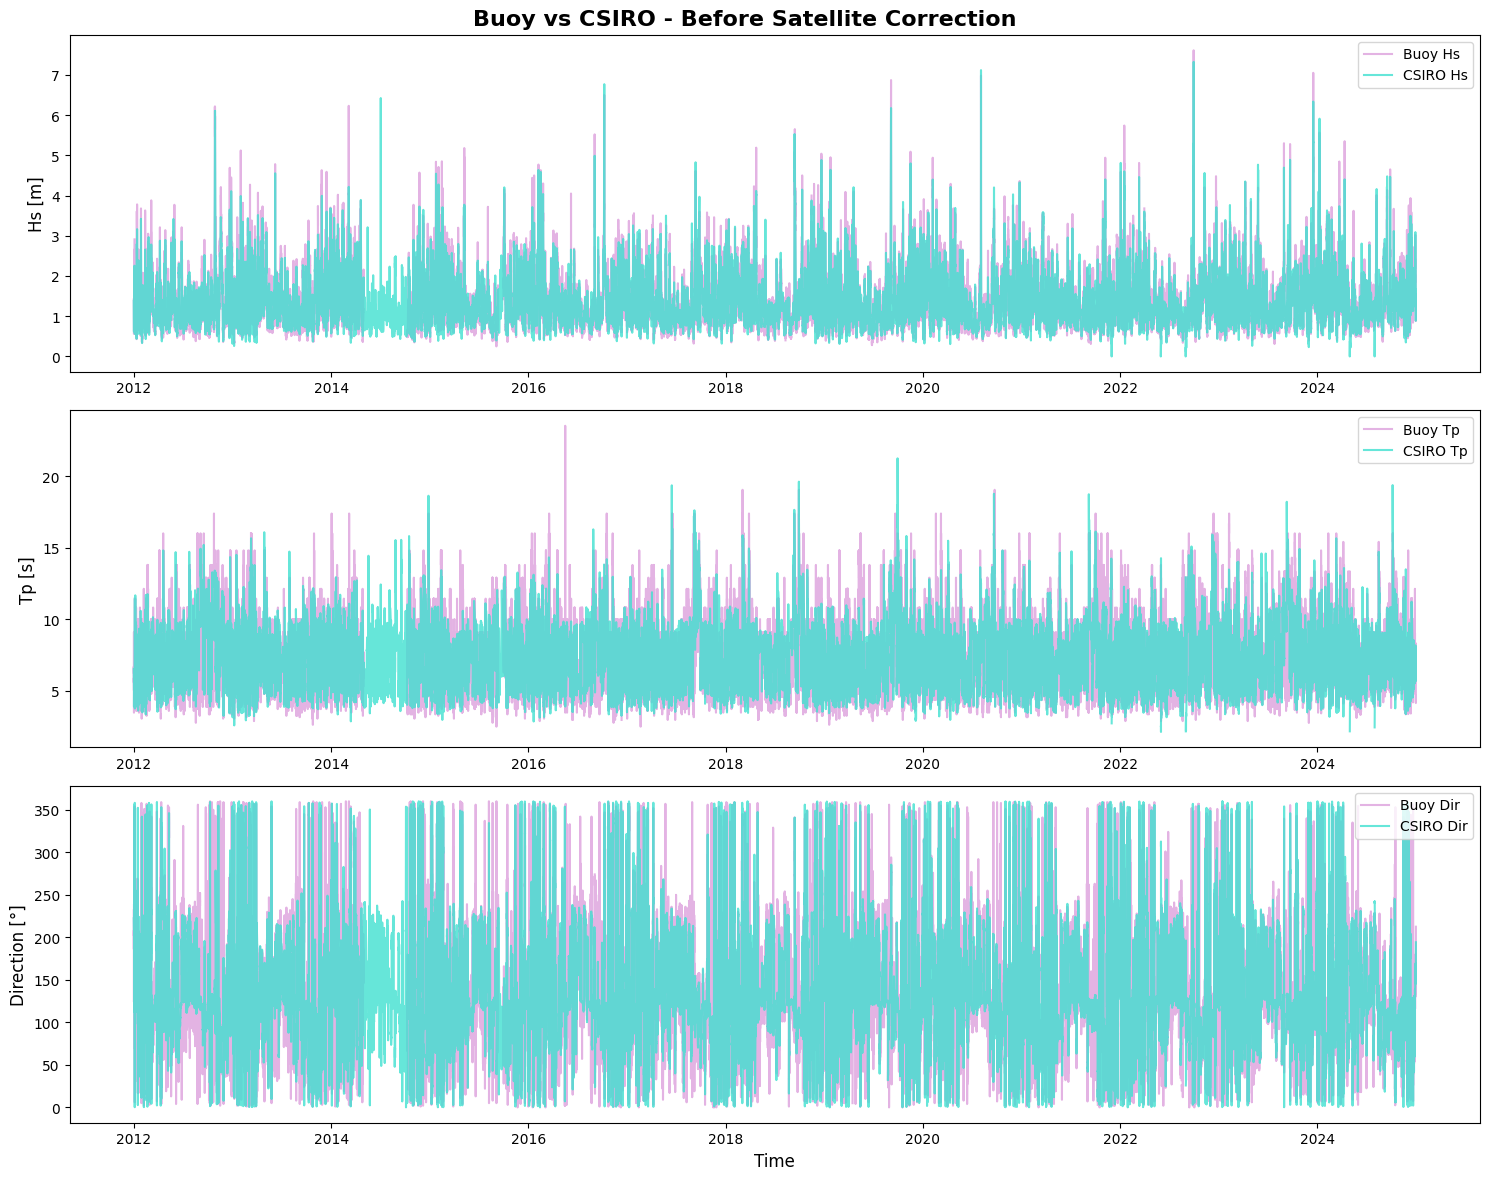

/tmp/ipykernel_1663405/713542253.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


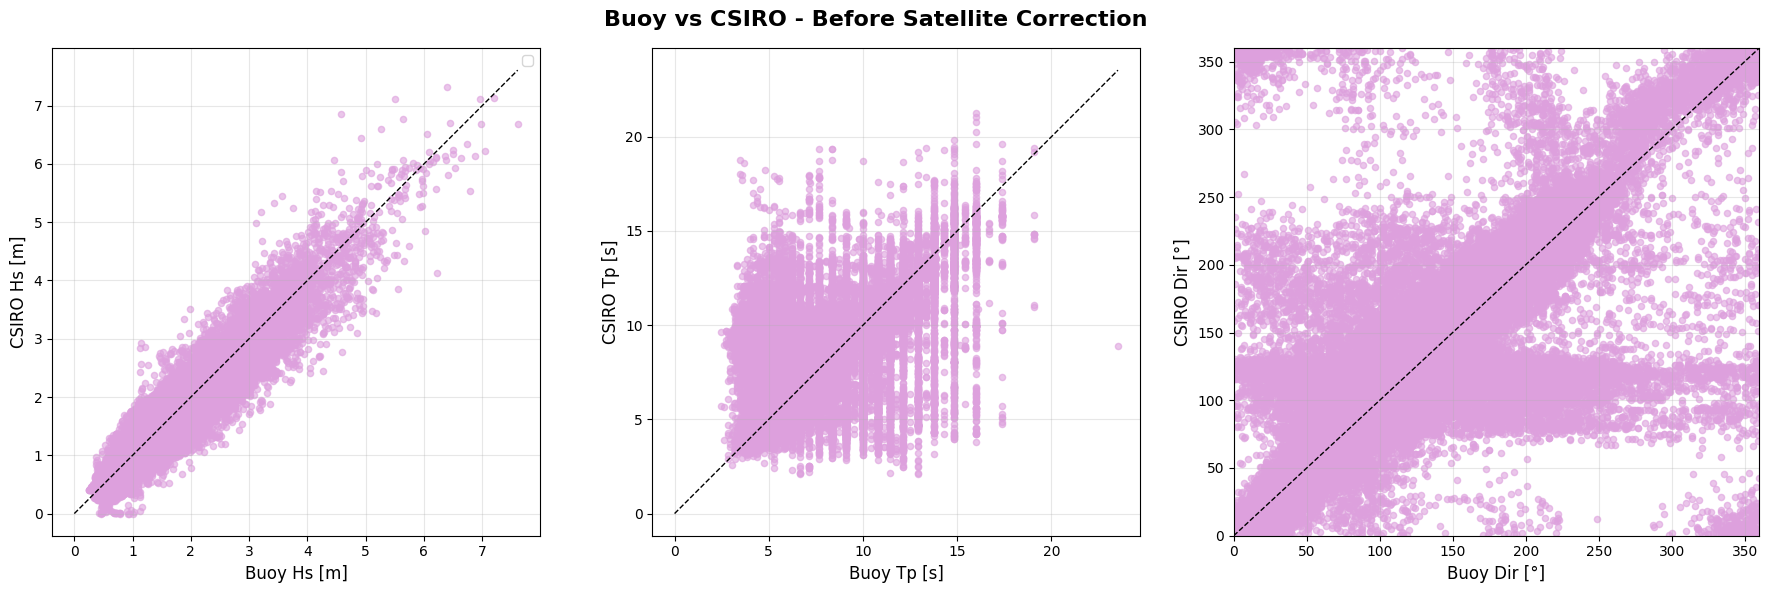

Data Statistics:
Common time period: 2011-12-31 23:00:00 to 2024-12-31 23:00:00
Number of common data points: 114133

Correlation coefficients:
Hs correlation: 0.950
Tp correlation: 0.611
Dir correlation: 0.689


In [7]:
# Plot comparison between buoy validation data and CSIRO data
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

# Create time series plot
fig1, axes = plt.subplots(3, 1, figsize=(15, 12))
fig1.suptitle('Buoy vs CSIRO - Before Satellite Correction', fontsize=16, fontweight='bold')

# Find common time range
common_start = max(buoy.index.min(), csiro.index.min())
common_end = min(buoy.index.max(), csiro.index.max())

# Filter data to common time range
buoy_common = buoy[(buoy.index >= common_start) & (buoy.index <= common_end)]
csiro_common = csiro[(csiro.index >= common_start) & (csiro.index <= common_end)]

# Hs time series
axes[0].plot(buoy_common.index, buoy_common['Hs_VAL'], color='plum', label='Buoy Hs', linewidth=1.5, alpha=0.8)
axes[0].plot(csiro_common.index, csiro_common['Hs'], color='turquoise', label='CSIRO Hs', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Hs [m]', fontsize=12)
axes[0].legend(fontsize=10)

# Tp time series
axes[1].plot(buoy_common.index, buoy_common['Tp_Buoy'], color='plum', label='Buoy Tp', linewidth=1.5, alpha=0.8)
axes[1].plot(csiro_common.index, csiro_common['Tp'], color='turquoise', label='CSIRO Tp', linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('Tp [s]', fontsize=12)
axes[1].legend(fontsize=10)

# Dir time series
axes[2].plot(buoy_common.index, buoy_common['Dir_Buoy'], color='plum', label='Buoy Dir', linewidth=1.5, alpha=0.8)
axes[2].plot(csiro_common.index, csiro_common['DirM'], color='turquoise', label='CSIRO Dir', linewidth=1.5, alpha=0.8)
axes[2].set_ylabel('Direction [°]', fontsize=12)
axes[2].set_xlabel('Time', fontsize=12)
axes[2].legend(fontsize=10)
plt.tight_layout()
plt.show()

# Create scatter plots
fig2, axes = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Buoy vs CSIRO - Before Satellite Correction', fontsize=16, fontweight='bold')

# Merge data on time index for scatter plots
merged_data = buoy_common.merge(csiro_common, left_index=True, right_index=True, how='inner')

# Hs scatter plot
axes[0].scatter(merged_data['Hs_VAL'], merged_data['Hs'], alpha=0.6, s=20, color='plum')
axes[0].plot([0, merged_data['Hs_VAL'].max()], [0, merged_data['Hs_VAL'].max()], 'k--', linewidth=1)
axes[0].set_xlabel('Buoy Hs [m]', fontsize=12)
axes[0].set_ylabel('CSIRO Hs [m]', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Tp scatter plot
axes[1].scatter(merged_data['Tp_Buoy'], merged_data['Tp'], alpha=0.6, s=20, color='plum')
axes[1].plot([0, merged_data['Tp_Buoy'].max()], [0, merged_data['Tp_Buoy'].max()], 'k--', linewidth=1)
axes[1].set_xlabel('Buoy Tp [s]', fontsize=12)
axes[1].set_ylabel('CSIRO Tp [s]', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

# Dir scatter plot
axes[2].scatter(merged_data['Dir_Buoy'], merged_data['DirM'], alpha=0.6, s=20, color='plum')
axes[2].plot([0, 360], [0, 360], 'k--', linewidth=1)
axes[2].set_xlabel('Buoy Dir [°]', fontsize=12)
axes[2].set_ylabel('CSIRO Dir [°]', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 360)
axes[2].set_ylim(0, 360)

plt.tight_layout()
plt.show()

# Print some statistics
print("Data Statistics:")
print(f"Common time period: {common_start} to {common_end}")
print(f"Number of common data points: {len(merged_data)}")
print("\nCorrelation coefficients:")
print(f"Hs correlation: {merged_data['Hs_VAL'].corr(merged_data['Hs']):.3f}")
print(f"Tp correlation: {merged_data['Tp_Buoy'].corr(merged_data['Tp']):.3f}")
print(f"Dir correlation: {merged_data['Dir_Buoy'].corr(merged_data['DirM']):.3f}")

> ⚠️ **NOTE:** A smaller radius (0.5 degrees) was selected for this correction—compared to the 1-degree radius used in Albuquerque et al., 2018—due to abrupt depth changes around the CAWCR point.

In [8]:
import pandas as pd
import xarray as xr
from bluemath_tk.waves.calibration import CalVal, process_imos_satellite_data


satellite_raw = xr.open_dataset("inputs/satellite_dataset_carolinas.nc")[
    [
        "SWH_KU_quality_control",
        "SWH_KA_quality_control",
        "SWH_KU_CAL",
        "SWH_KA_CAL",
        "BOT_DEPTH",
    ]
].to_dataframe()
satellite_processed = process_imos_satellite_data(
    satellite_df=satellite_raw,
    ini_lat=station_lat-.5,
    end_lat=station_lat+.5,
    ini_lon=station_lon-.5,
    end_lon=station_lon+.5,
    depth_threshold=-20,
)
satellite_processed

/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  satellite_df["Hs_CAL"] = np.nansum(


,SWH_KU_quality_control,SWH_KA_quality_control,SWH_KU_CAL,SWH_KA_CAL,BOT_DEPTH,LATITUDE,LONGITUDE,Hs_CAL
TIME,,,,,,,,
1985-03-31 10:49:11.765629649,1.0,NaN,1.193,NaN,-293.0,32.973892,282.613251,1.193
1985-03-31 10:49:12.750003710,1.0,NaN,1.116,NaN,-261.0,33.028099,282.583618,1.116
1985-03-31 10:49:13.726562485,1.0,NaN,1.260,NaN,-238.0,33.082298,282.553955,1.260
1985-03-31 10:49:14.710936546,1.0,NaN,0.952,NaN,-155.0,33.136494,282.524231,0.952
1985-03-31 10:49:15.687495321,1.0,NaN,0.741,NaN,-69.0,33.190681,282.494507,0.741
...,...,...,...,...,...,...,...,...
2024-12-31 22:52:09.515621120,1.0,NaN,1.185,NaN,-25.0,33.669189,282.435913,1.185
2024-12-31 22:52:10.515625728,1.0,NaN,1.014,NaN,-27.0,33.725819,282.418304,1.014
2024-12-31 22:52:11.515620352,1.0,NaN,0.990,NaN,-25.0,33.782448,282.400635,0.990


In [9]:
calval = CalVal()
calval

In [10]:
from bluemath_tk.waves.calibration import CalVal, process_imos_satellite_data

/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:348: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if direcs[i] < 0:
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:350: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if direcs[i] > 0 and waves[i] > 0:
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:352: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consiste

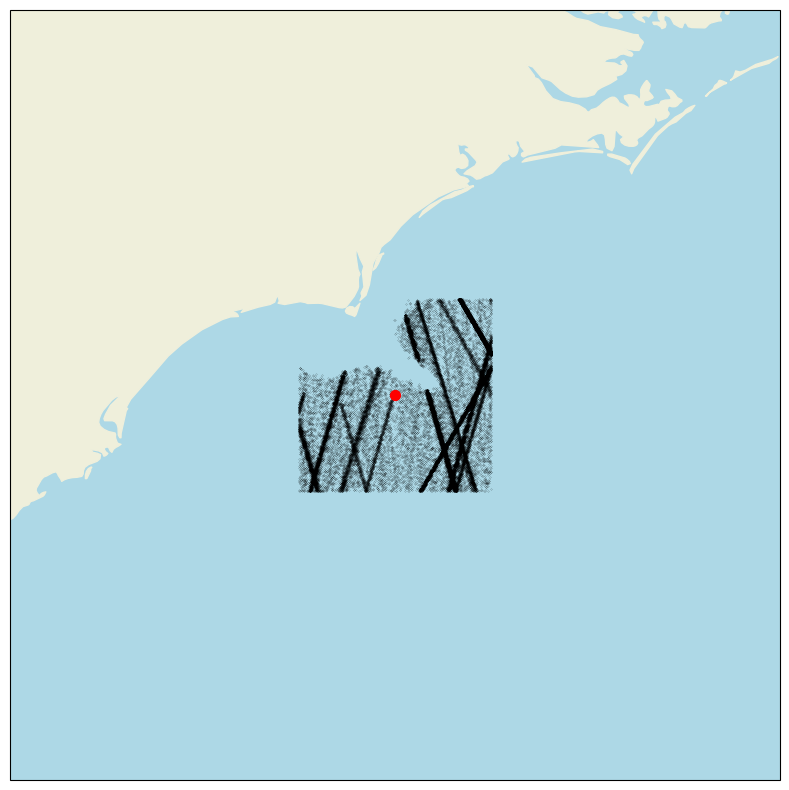

In [11]:
calval.fit(
    data=csiro,
    data_longitude=csiro_lon,
    data_latitude=csiro_lat,
    data_to_calibrate=satellite_processed,
    max_time_diff=1,
)

In [12]:
calval.calibration_params

{'sea_correction': {0: np.float64(0.35602755138254544),
  1: np.float64(1.0),
  2: np.float64(1.0),
  3: np.float64(1.0),
  4: np.float64(1.5206599502982914),
  5: np.float64(0.73241299564179),
  6: np.float64(1.0826014974965485),
  7: np.float64(0.8473129714518365),
  8: np.float64(1.060454644923435),
  9: np.float64(0.907433929367412),
  10: np.float64(1.2190105975497363),
  11: np.float64(1.0),
  12: np.float64(1.0),
  13: np.float64(1.0),
  14: np.float64(1.0),
  15: np.float64(1.0)},
 'swell_correction': {0: np.float64(1.381144213865358),
  1: np.float64(1.5424778201065705),
  2: np.float64(1.171437787939814),
  3: np.float64(1.1661658490974738),
  4: np.float64(1.2665622534620975),
  5: np.float64(1.0462678605921698),
  6: np.float64(1.102914256422431),
  7: np.float64(1.0140745987292659),
  8: np.float64(1.304274280995076),
  9: np.float64(0.9758301879101766),
  10: np.float64(1.0318801768809034),
  11: np.float64(1.1616925554292135),
  12: np.float64(1.2565230554283506),
  13: 

/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/core/plotting/scatter.py:114: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x1, y1, z = x[idx], y[idx], z[idx]
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:772: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/core/plotting/scatter.py:114: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value b

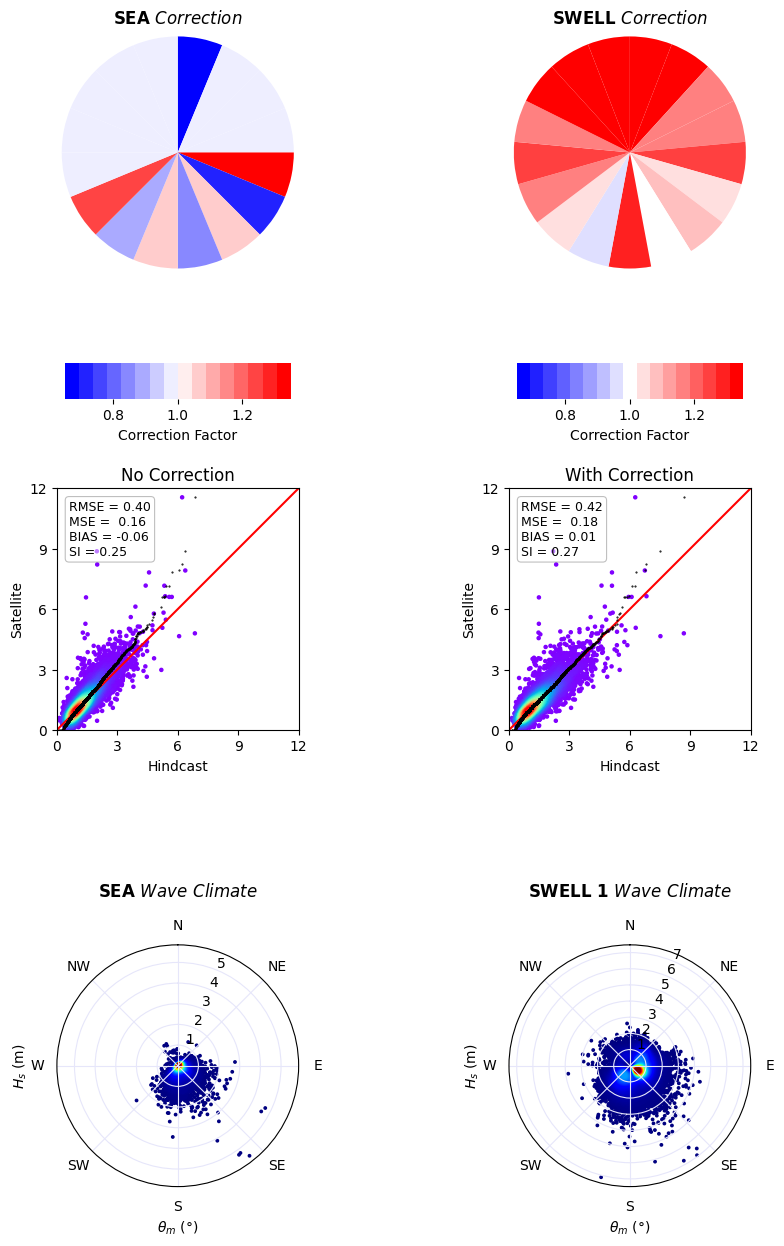

In [13]:
calval.plot_calibration_results();

In [14]:
corrected_csiro = calval.correct(data=csiro)
corrected_csiro

,Hs,Hs_CORR
1979-01-01 00:00:00,0.000000,0.000000
1979-01-01 01:00:00,0.241804,0.330943
1979-01-01 02:00:00,0.344735,0.398033
1979-01-01 03:00:00,0.396738,0.431554
1979-01-01 04:00:00,0.507530,0.560011
...,...,...
2025-03-31 20:00:00,1.943144,2.054852
2025-03-31 21:00:00,1.916491,2.052476
2025-03-31 22:00:00,1.909118,1.992642
2025-03-31 23:00:00,1.925956,1.920974


Text(0, 0.5, 'CSIRO Corrected Hs [m]')

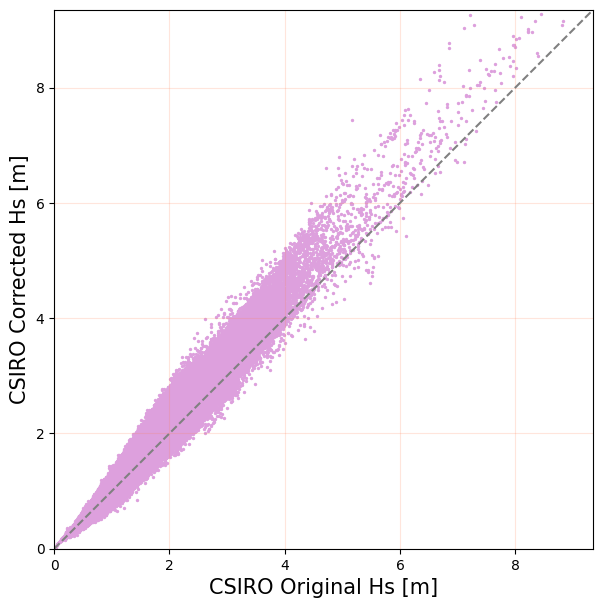

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Fix the subplot creation
fig, ax = plt.subplots(figsize=[20, 7])

ax.scatter(corrected_csiro.Hs, corrected_csiro.Hs_CORR, c='plum', s=2)
ax.plot([0, np.nanmax(corrected_csiro.Hs)+.2], [0, np.nanmax(corrected_csiro.Hs)+.2], '--', color='gray')
ax.set_aspect('equal')
ax.set_xlim([0, np.nanmax(corrected_csiro.Hs)+.2])
ax.set_ylim([0, np.nanmax(corrected_csiro.Hs)+.2])
ax.grid(color='coral', alpha=.2)
ax.set_xlabel('CSIRO Original Hs [m]', fontsize=15)
ax.set_ylabel('CSIRO Corrected Hs [m]', fontsize=15)

## Correcting spectrum for BinWaves

In [16]:
dirs=np.arange(0,360.5,22.5)
dirs

array([  0. ,  22.5,  45. ,  67.5,  90. , 112.5, 135. , 157.5, 180. ,
       202.5, 225. , 247.5, 270. , 292.5, 315. , 337.5, 360. ])

In [17]:
params_seas = list(calval.calibration_params['sea_correction'].values())
params_swells=list(calval.calibration_params['swell_correction'].values())

In [18]:
# Set up data paths
p_spec = op.join(os.getcwd(), 'inputs') 
station = '4466_spec'  # Station identifier

In [19]:
correct_spec = False
spec_parts = xr.open_dataset(op.join('outputs', 'CAWCR_spectral_parts_4466.nc'))
if correct_spec:
    DS_a=[]

    for p in range(len(spec_parts.part.values)):
        if p==0:
            ps=params_seas
        else:
            ps=params_swells
        DS=[]        
        for d in range(len(dirs)-1):      

            s=np.where((spec_parts.dir.values>dirs[d]) & (spec_parts.dir.values<=dirs[d+1]))[0]
            DS.append((ps[d]**2)*spec_parts['efth'].sel(part=p).isel(dir=s))
        DS_a.append(xr.concat(DS, dim='dir'))
    DS_a=xr.concat(DS_a, dim='part') 
    DS_a = DS_a.sum(dim = 'part').to_dataset()
 
    DS_a['Depth'] = (('time'), cawcr_spectrum.Depth.values)
    DS_a['Wspeed'] = (('time'), cawcr_spectrum.Wspeed.values)
    DS_a['Wdir'] = (('time'), cawcr_spectrum.Wdir.values)
    DS_a['longitude'] = (('time'), cawcr_spectrum.longitude.values)
    DS_a['latitude'] = (('time'), cawcr_spectrum.latitude.values)
    
    
    DS_a.to_netcdf(op.join(p_spec, '{}_satellite_corrected.nc'.format(station)))
    DS_a=xr.open_dataset(op.join(p_spec, '{}_satellite_corrected.nc'.format(station)))
else:
    DS_a=xr.open_dataset(op.join(p_spec, '{}_satellite_corrected.nc'.format(station)))

print(DS_a)

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 405963, freq: 29, dir: 24)
Coordinates:
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    station    int32 4B ...
  * freq       (freq) float32 116B 0.035 0.0385 0.04235 ... 0.4171 0.4589 0.5047
  * dir        (dir) float32 96B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
Data variables:
    efth       (time, freq, dir) float64 2GB ...
    Depth      (time) float32 2MB ...
    Wspeed     (time) float32 2MB ...
    Wdir       (time) float32 2MB ...
    longitude  (time) float32 2MB ...
    latitude   (time) float32 2MB ...


### Comparison Wave Buoy vs Corrected CAWCR spectrum

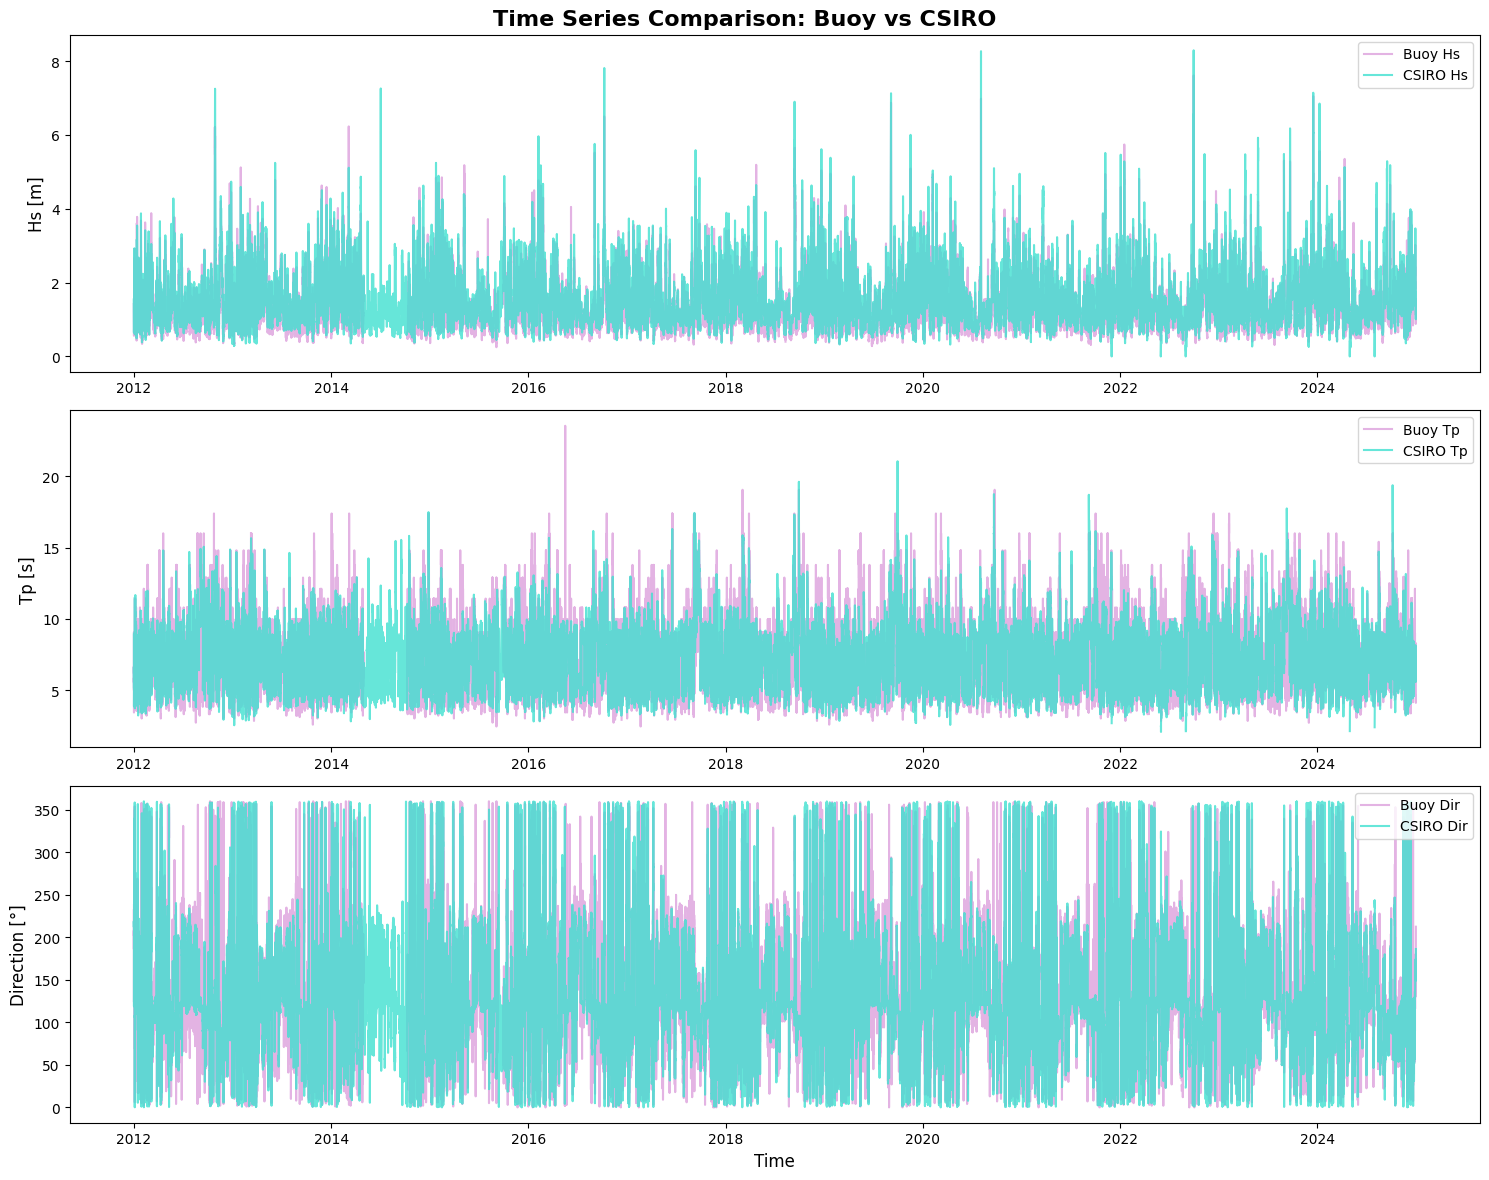

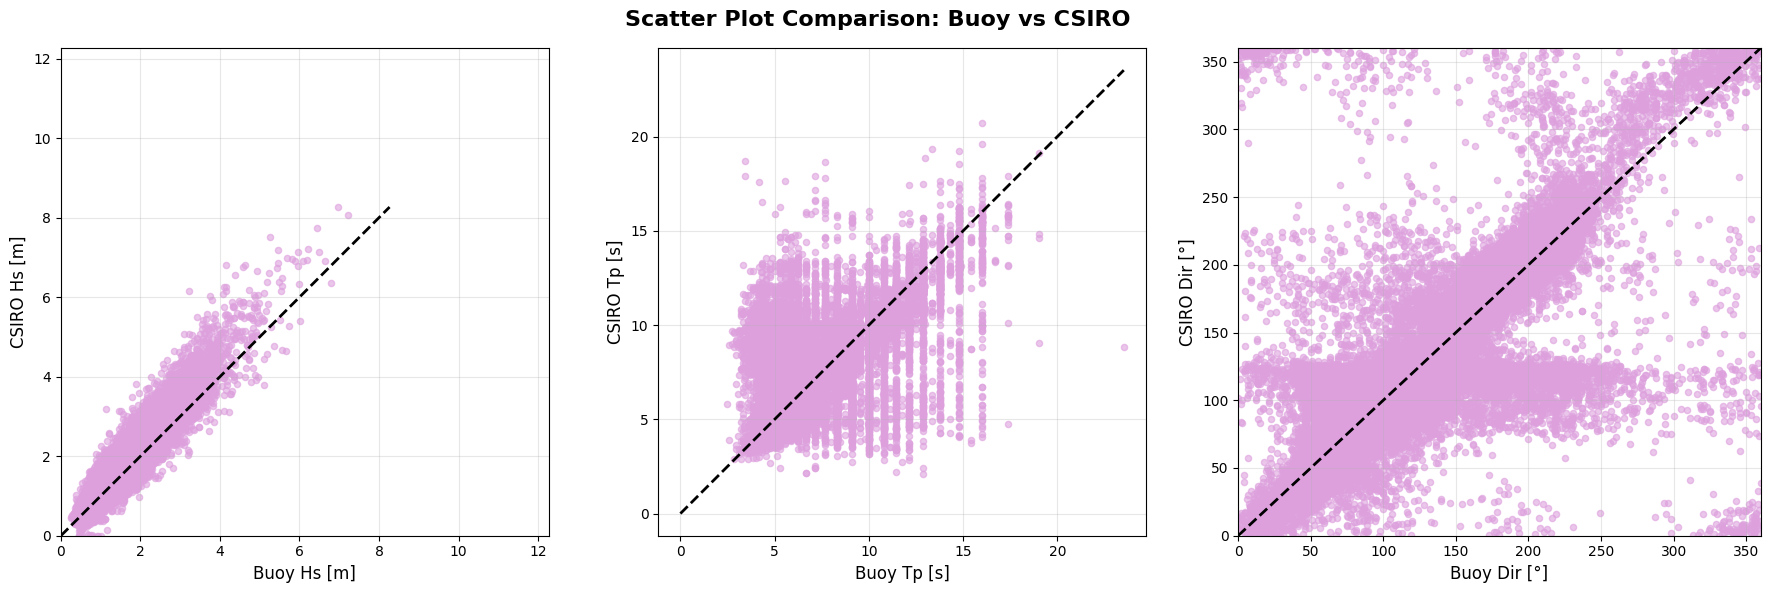

Data Statistics:
Common time period: 2011-12-31 23:00:00 to 2024-12-31 23:00:00
Number of common data points: 38148

Correlation coefficients:
Hs correlation: 0.946
Tp correlation: 0.611
Dir correlation: 0.698


In [20]:
# Create time series plot
fig1, axes = plt.subplots(3, 1, figsize=(15, 12))
fig1.suptitle('Time Series Comparison: Buoy vs CSIRO', fontsize=16, fontweight='bold')

# Find common time range
common_start = max(buoy.index.min(), DS_a.time.min())
common_end = min(buoy.index.max(), DS_a.time.max())

# Filter data to common time range
buoy_common = buoy[(buoy.index >= common_start) & (buoy.index <= common_end)]
csiro_common = DS_a.sel(time=slice(common_start, common_end))

# Hs time series
axes[0].plot(buoy_common.index, buoy_common['Hs_VAL'], color ='plum', label='Buoy Hs', linewidth=1.5, alpha=0.8)
axes[0].plot(csiro_common.time, csiro_common.spec.hs().values, color='turquoise', label='CSIRO Hs', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Hs [m]', fontsize=12)
axes[0].legend(fontsize=10)

# Tp time series
axes[1].plot(buoy_common.index, buoy_common['Tp_Buoy'], color ='plum', label='Buoy Tp', linewidth=1.5, alpha=0.8)
axes[1].plot(csiro_common.time, csiro_common.spec.tp().values, color='turquoise', label='CSIRO Tp', linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('Tp [s]', fontsize=12)
axes[1].legend(fontsize=10)

# Dir time series
axes[2].plot(buoy_common.index, buoy_common['Dir_Buoy'], color ='plum', label='Buoy Dir', linewidth=1.5, alpha=0.8)
axes[2].plot(csiro_common.time, csiro_common.spec.dpm().values, color='turquoise', label='CSIRO Dir', linewidth=1.5, alpha=0.8)
axes[2].set_ylabel('Direction [°]', fontsize=12)
axes[2].set_xlabel('Time', fontsize=12)
axes[2].legend(fontsize=10)
plt.tight_layout()
plt.show()

csiro_df = pd.DataFrame({
    'Hs': csiro_common.spec.hs().values,
    'Tp': csiro_common.spec.tp().values,
    'DirM': csiro_common.spec.dpm().values
}, index=csiro_common.time.values)
# Create scatter plots
fig2, axes = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Scatter Plot Comparison: Buoy vs CSIRO', fontsize=16, fontweight='bold')

# Merge data on time index for scatter plots
merged_data = buoy_common.merge(csiro_df, left_index=True, right_index=True, how='inner')

# Hs scatter plot
axes[0].scatter(merged_data['Hs_VAL'], merged_data['Hs'], alpha=0.6, s=20, color='plum')
axes[0].plot([0, merged_data['Hs'].max()], [0, merged_data['Hs'].max()], 'k--', linewidth=2, label='1:1 line')
axes[0].set_xlabel('Buoy Hs [m]', fontsize=12)
axes[0].set_ylabel('CSIRO Hs [m]', fontsize=12)
axes[0].set_xlim(0, merged_data['Hs'].max()+4)
axes[0].set_ylim(0, merged_data['Hs'].max()+4)
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Tp scatter plot
axes[1].scatter(merged_data['Tp_Buoy'], merged_data['Tp'], alpha=0.6, s=20, color='plum')
axes[1].plot([0, merged_data['Tp_Buoy'].max()], [0, merged_data['Tp_Buoy'].max()], 'k--', linewidth=2, label='1:1 line')
axes[1].set_xlabel('Buoy Tp [s]', fontsize=12)
axes[1].set_ylabel('CSIRO Tp [s]', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

# Dir scatter plot
axes[2].scatter(merged_data['Dir_Buoy'], merged_data['DirM'], alpha=0.6, s=20, color='plum')
axes[2].plot([0, 360], [0, 360], 'k--', linewidth=2, label='1:1 line')
axes[2].set_xlabel('Buoy Dir [°]', fontsize=12)
axes[2].set_ylabel('CSIRO Dir [°]', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 360)
axes[2].set_ylim(0, 360)

plt.tight_layout()
plt.show()

# Print some statistics
print("Data Statistics:")
print(f"Common time period: {common_start} to {common_end}")
print(f"Number of common data points: {len(merged_data)}")
print("\nCorrelation coefficients:")
print(f"Hs correlation: {merged_data['Hs_VAL'].corr(merged_data['Hs']):.3f}")
print(f"Tp correlation: {merged_data['Tp_Buoy'].corr(merged_data['Tp']):.3f}")
print(f"Dir correlation: {merged_data['Dir_Buoy'].corr(merged_data['DirM']):.3f}")

### Comparison Raw CAWCR vs Corrected CAWCR

Text(0.5, 0, 'Original Dpm [º]')

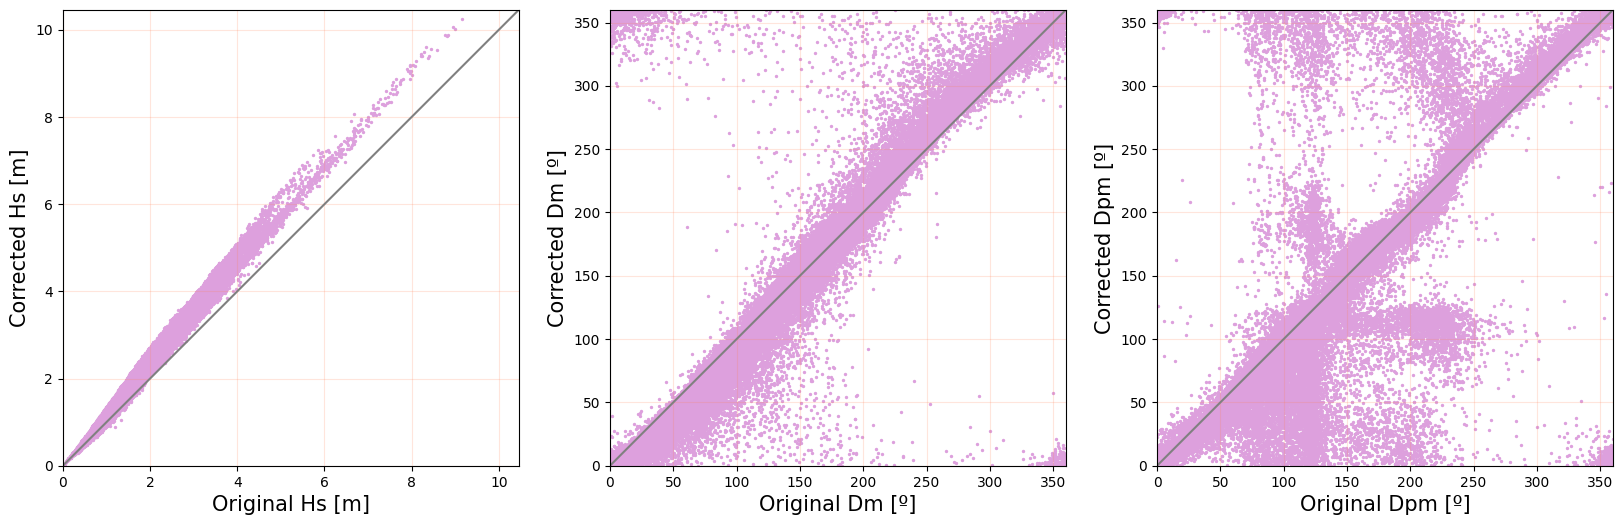

In [21]:
csiro_spec = cawcr_spectrum 
fig, axs = plt.subplots(1, 3,  figsize = [20, 7])

ax = axs[0]
ax.scatter(csiro_spec.efth.spec.hs().values, DS_a.spec.hs().values, c = 'plum', s = 2)
ax.plot([0, np.nanmax(DS_a.spec.hs())+.2], [0, np.nanmax(DS_a.spec.hs()+.2)], color = 'grey')
ax.set_aspect('equal')
ax.set_xlim([0, np.nanmax(DS_a.spec.hs())+.2])
ax.set_ylim([0, np.nanmax(DS_a.spec.hs())+.2])
ax.grid(color = 'coral', alpha = .2)
ax.set_xlabel('Original Hs [m]', fontsize = 15)
ax.set_ylabel('Corrected Hs [m]', fontsize = 15)


ax = axs[1]
ax.scatter(csiro_spec.efth.spec.dm().values,DS_a.spec.dm().values,  c = 'plum', s = 2)
ax.plot([0, 360], [0, 360], color = 'grey')
ax.set_aspect('equal')
ax.set_xlim([0, 360])
ax.set_ylim([0, 360])
ax.grid(color = 'coral', alpha = .2)
ax.set_ylabel('Corrected Dm [º]', fontsize = 15)
ax.set_xlabel('Original Dm [º]', fontsize = 15)

ax = axs[2]
ax.scatter( csiro_spec.efth.spec.dpm().values,DS_a.spec.dpm().values, c = 'plum', s = 2)
ax.plot([0, 360], [0, 360], color = 'grey')
ax.set_aspect('equal')
ax.set_xlim([0, 360])
ax.set_ylim([0, 360])
ax.grid(color = 'coral', alpha = .2)
ax.set_ylabel('Corrected Dpm [º]', fontsize = 15)
ax.set_xlabel('Original Dpm [º]', fontsize = 15)